In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [2]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import joblib

In [3]:
# ==========================
# Step 2: Load Dataset
# ==========================

df = pd.read_csv("Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
# ==========================
# Step 3: Dataset Information
# ==========================

print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# ==========================
# Step 4: Data Cleaning
# ==========================

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_18792/1550894319.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [6]:
# ==========================
# Step 5: Encode Categorical Columns
# ==========================

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])


In [7]:
# ==========================
# Step 6: Split Features and Target
# ==========================

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [8]:
# ==========================
# Step 7: Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# ==========================
# Step 8: Train Model
# ==========================

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# ==========================
# Step 9: Prediction
# ==========================

y_pred = model.predict(X_test)

# ==========================
# Step 10: Accuracy
# ==========================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7955997161107168


[[945  91]
 [197 176]]


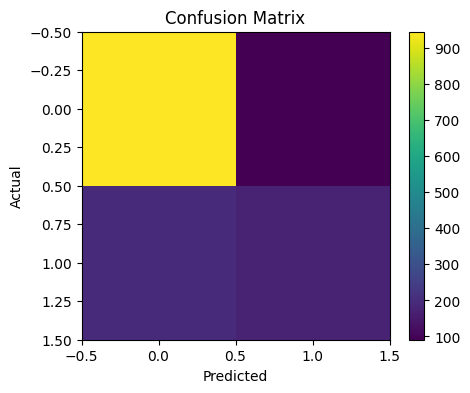

In [10]:
# ==========================
# Step 11: Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [11]:
# ==========================
# Step 12: Classification Report
# ==========================

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



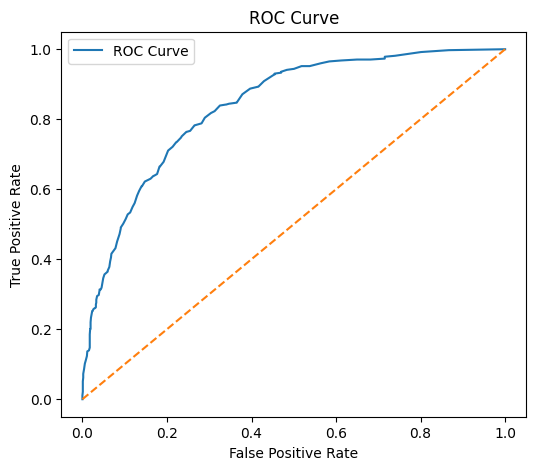

ROC AUC Score : 0.8369592783131656


In [12]:
# ==========================
# Step 13: ROC Curve
# ==========================

prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, prob)

auc = roc_auc_score(y_test, prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC Score :", auc)

TotalCharges        0.189992
MonthlyCharges      0.177867
tenure              0.157428
Contract            0.077357
PaymentMethod       0.050379
OnlineSecurity      0.047432
TechSupport         0.044190
gender              0.028117
OnlineBackup        0.027067
InternetService     0.026444
PaperlessBilling    0.024917
Partner             0.023864
MultipleLines       0.023131
DeviceProtection    0.021012
Dependents          0.020709
SeniorCitizen       0.020354
StreamingMovies     0.017737
StreamingTV         0.016749
PhoneService        0.005254
dtype: float64


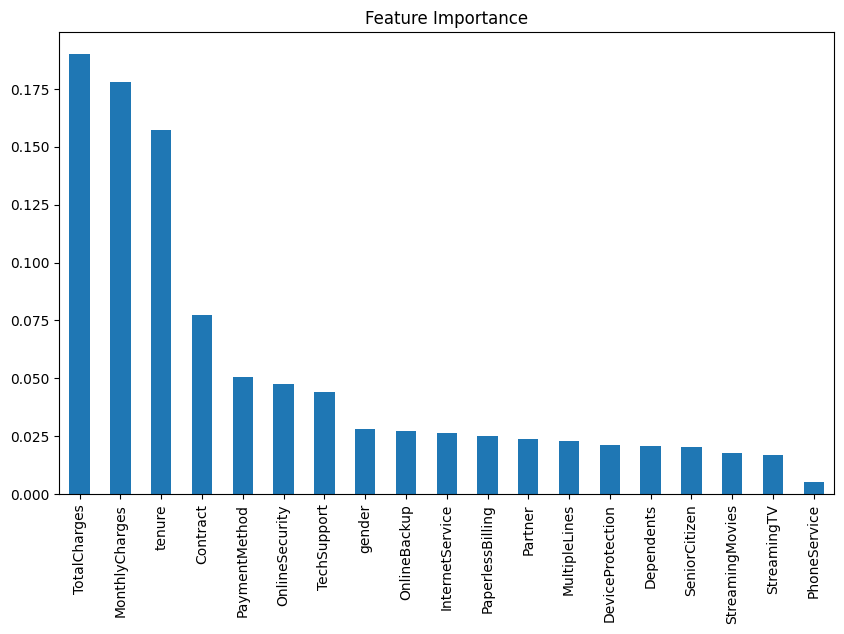

In [13]:
# ==========================
# Step 14: Feature Importance
# ==========================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.show()

In [14]:
# ==========================
# Step 15: Save Model
# ==========================

joblib.dump(model, "churn_model.pkl")

print("Model Saved Successfully!")


Model Saved Successfully!


In [15]:
# ==========================
# Step 16: Predict New Customer
# ==========================

new_customer = X.iloc[[0]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to Churn.")
else:
    print("Customer is NOT likely to Churn.")

Customer is NOT likely to Churn.
